In-Silico Perturbation Workflow for Single-Cell Foundation Models

**What is this?:** A computational framework for simulating gene knock-down and knock-up events in single-cell transcriptomic data, leveraging GeneFormer V2's rank-value encoded representations to measure perturbation effects in a biologically informed latent space?

---

## Scientific Context

Single-cell foundation models such as GeneFormer V2 (Theodoris et al., *Nature* 2023) encode each cell as a rank-ordered sequence of expressed genes, where rank position reflects relative expression within the cellular transcriptome. This rank-value encoding creates a natural perturbation interface: altering a gene's expression changes its rank position, which propagates through the transformer's attention layers to shift the cell's embedding in latent space.

**Important: Approach design rationale and SOTA context:**  
The SOTA perturbation prediction methods such as STATE (Arc Institute, 2025) and scREPA (CSBJ, 2025) aim to predict full post-perturbation transcriptomes and can be evaluated against held-out experimental data (e.g., Perturb-seq screens). These represent the gold standard for in-silico perturbation prediction. However, they require either purpose-built perturbation-scale training data or extensive data for fine-tuning, as well as costly computing infrastructure.

This approach is **embedding perturbation framework**: I modify the input transcriptome to simulate a perturbation, re-embed using GeneFormer V2's pretrained representations, and analyse the resulting shift in latent space. This approach is methodologically grounded in Theodoris et al. (2023), who demonstrated that in-silico deletion of individual genes from GeneFormer's input ranking produced biologically meaningful embedding shifts, identifying candidate therapeutic targets in cardiomyopathy. The scISP framework (2025) further validated that cosine shift magnitudes >1×10⁻⁴ are indicative of therapeutic target potential.

I acknowledge that this approach does not predict downstream gene expression cascades and should be interpreted as measuring **first-order embedding sensitivity** — a necessary but not sufficient condition for biological perturbation response.

**Key methodological innovations in this workflow:**
1. **Rank-based perturbation encoding** aligned with GeneFormer's native tokenisation paradigm
2. **Cosine shift metrics** (field standard) rather than L2 distance
3. **Random gene null distribution** with FDR correction for statistical rigour
4. **Dose-response perturbation** inspired by GeneCompass (Yang et al., *Cell Research* 2024)
5. **Mean healthy baseline** as theoretical upper bound for rescue score normalisation

**Inputs:** Preprocessed `.h5ad` (ALS motor cortex, Pineda et al. *Cell* 2024)  
**Outputs:** Validated `InSilicoPerturbation` class, demonstration on test cells  
**Dependencies:** `helical`, `scanpy`, `numpy`, `scipy`, `scikit-learn`  
**Compute:** AWS g5.xlarge (NVIDIA A10G, 24 GB VRAM)

## 1. Environment Setup

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np
import scanpy as sc
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import sys
import torch
from typing import List, Optional, Dict, Tuple, Union
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy import stats
from pathlib import Path

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ── DEVICE SETUP ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ No GPU detected. Embeddings are slow on CPU.")

# ── PATHS ────────────────────────────────────────────────────────────────────
# Resolve paths relative to notebook location
NOTEBOOK_DIR = Path('.').resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
SRC_DIR = PROJECT_ROOT / 'src'

# Create output directories if needed
FIGURES_DIR.mkdir(exist_ok=True)

# Add src/ to path for reusable modules
sys.path.insert(0, str(SRC_DIR))

print(f"\nProject root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

# ── VERSION INFO ─────────────────────────────────────────────────────────────
print(f"\nPython:  {sys.version.split()[0]}")
print(f"NumPy:   {np.__version__}")
print(f"Scanpy:  {sc.__version__}")
print(f"PyTorch: {torch.__version__}")
print("\n✓ Environment ready.")

/home/ubuntu/miniconda3/envs/helical/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


PyTorch device: cuda
GPU: NVIDIA A10G
VRAM: 23.7 GB

Project root: /home/ubuntu/repos/scfm-helical-geneformer
Data dir:     /home/ubuntu/repos/scfm-helical-geneformer/data
Figures dir:  /home/ubuntu/repos/scfm-helical-geneformer/figures

Python:  3.10.20
NumPy:   2.2.6
Scanpy:  1.11.5
PyTorch: 2.7.0+cu126

✓ Environment ready.


/tmp/ipykernel_4608/1667033897.py:56: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy:  {sc.__version__}")


## 2. Phase 0: API checks and data exploration

Before writing any perturbation logic, I must test how to interface with the Helical GeneFormer V2 wrapper. 

### 2.1 GeneFormer V2 API check

In [2]:
# ── HELICAL API EXPLORATION ──────────────────────────────────────────────────

from helical.models.geneformer import Geneformer, GeneformerConfig
import inspect
import glob
from pathlib import Path

# Initialise model — check if GeneformerConfig accepts a device parameter
print("=== Initialising GeneFormer V2 (gf-12L-95M-i4096) ===\n")

try:
    # Try with device parameter first (preferred for GPU)
    config = GeneformerConfig(model_name="gf-12L-95M-i4096", device=device)
    print(f"✓ GeneformerConfig accepts device parameter: {device}")
except TypeError:
    # Fall back to default — may need manual .to(device) later
    config = GeneformerConfig(model_name="gf-12L-95M-i4096")
    print("ℹ GeneformerConfig does NOT accept device parameter!")
    print("Check Helical docs for GPU usage ... ")

model = Geneformer(configurer=config)

print("\n=== process_data signature ===")
print(inspect.signature(model.process_data))

print("\n=== get_embeddings signature ===")
print(inspect.signature(model.get_embeddings))


# Helical wraps the tokenizer internally.
gf_genes = set()
token_dict = None
# Helical caches models in ~/.cache/helical/ 
cache_dir = Path.home() / '.cache' / 'helical'
pkl_files = list(cache_dir.rglob('*token_dictionary*.pkl')) if cache_dir.exists() else []
if pkl_files:
    import pickle
    with open(pkl_files[0], 'rb') as f:
        token_dict = pickle.load(f)
        print(f"✓ Found token dictionary at {pkl_files[0]}: {len(token_dict)} entries")
        

if token_dict is None:
    print("⚠ ⚠ Could not locate token dictionary from model attributes or cache.")
    print("⚠ ⚠ This means we cannot pre-check which genes are in GeneFormer's vocabulary,")

2026-03-15 10:14:52,097 - WARNING:py.warnings:/home/ubuntu/miniconda3/envs/helical/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

2026-03-15 10:14:52,206 - INFO:datasets:PyTorch version 2.7.0 available.
2026-03-15 10:14:57,487 - WARNING:helical.models.geneformer.geneformer_config:Setting model to gf-12L-38M-i4096. Model name gf-12L-95M-i4096 is deprecated. Please use the new name going forward to avoid code breakages.Geneformer models have been renamed to better reflect their size.


=== Initialising GeneFormer V2 (gf-12L-95M-i4096) ===

✓ GeneformerConfig accepts device parameter: cuda


2026-03-15 10:14:59,472 - INFO:helical.models.geneformer.model:Model finished initializing.
2026-03-15 10:14:59,472 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.



=== process_data signature ===
(adata: anndata._core.anndata.AnnData, gene_names: str = 'index', output_path: Optional[str] = None, use_raw_counts: bool = True) -> datasets.arrow_dataset.Dataset

=== get_embeddings signature ===
(dataset: datasets.arrow_dataset.Dataset, output_attentions: bool = False, output_genes: bool = False) -> <built-in function array>
✓ Found token dictionary at /home/ubuntu/.cache/helical/models/geneformer/v2/token_dictionary.pkl: 20275 entries


### 2.2 Comprehensive Data Audit

The curated dataset (`counts_combined_filtered_BA4_sALS_PN.h5ad`) is a subset data from Pineda et al. (*Cell* 2024) where the whole dataset contains a snRNA-seq atlas of ~380,000 nuclei from the human motor and prefrontal cortices in ALS and FTLD. The filename indicates that the dataset was subsetted to: **BA4** (primary motor cortex), **sALS** (sporadic ALS), and **PN** (pathologically normal controls).

In [3]:
# ── DATA LOADING ─────────────────────────────────────────────────────────────
DATA_PATH = DATA_DIR / 'counts_combined_filtered_BA4_sALS_PN.h5ad'
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        f'Download: curl -o {DATA_PATH} "<S3_PRESIGNED_URL_FROM_CHALLENGE_BRIEF>"'
    )
adata = sc.read_h5ad(str(DATA_PATH))

# ── AUDIT ────────────────────────────────────────────────────────────────────
print(adata)  # shape + obs/var columns

print("\n=== CONDITION / GROUP ===")
for col in ['Condition', 'Group']:
    print(f"  {col}: {adata.obs[col].value_counts().to_dict()}")

print("\n=== CELL TYPE LABELS ===")
for col in ['CellClass', 'CellType', 'SubType', 'Bakken_M1',
            'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3']:
    print(f"\n  {col} (top 20):\n{adata.obs[col].value_counts().head(20).to_string()}")

print("\n=== COUNT MATRIX FORMAT ===")
sample = adata.X[:100, :500]
nz = (sample.toarray() if sp.issparse(sample) else sample).flatten()
nz = nz[nz > 0]
print(f"  type={type(adata.X).__name__}, dtype={adata.X.dtype}")
print(f"  integers={np.all(nz == nz.astype(int))}, max={nz.max():.2f}, min_nz={nz.min():.4f}")
print(f"  sample: {nz[:15]}")


AnnData object with n_obs × n_vars = 112014 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'biotype'

=== CONDITION / GROUP ===
  Condition: {'ALS': 66960, 'PN': 45054}
  Group: {'SALS': 66960, 'PN': 45054}

=== CELL TYPE LABELS ===

  CellClass (top 20):
CellClass
Glia    46402
Ex      45322
In      18018
Vasc     2272

  CellType (top 20):
CellType
Oligo      19043
Astro      13178
L2_L3      11871
OPC         9416
L3_L5       9331
L4_L6  

### 2.2.1 Target Cell Populations

Based on Pineda et al.: **L5 VAT1L+ EYA4** (Betz/upper motor neuron cells) are the most transcriptionally affected cell type in sALS motor cortex, showing ~30% depletion and confirmed TDP-43 pathology. **L3/L5 SCN4B+ NEFH** are the secondary vulnerable population.

**Dataset structure (confirmed):**
- **112,014 cells × 22,832 genes** (gene symbols, not Ensembl IDs)
- Disease labels: `Group` column → `SALS` (66,960) / `PN` (45,054)
- Cell types: `SubType` column → `VAT1L_EYA4`, `VAT1L_THSD4`, `SCN4B_NEFH`
- Note: 33,401 cells have NaN in SubType — use `CellType` for broad classification
- Cell classes: Ex (45,322), Glia (46,402), In (18,018), Vasc (2,272)

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# (112,014 cells × 22,832 genes, gene symbols)
# ══════════════════════════════════════════════════════════════════════════════

CELL_TYPE_COL  = 'SubType'    # VAT1L_EYA4, VAT1L_THSD4, SCN4B_NEFH
CELL_CLASS_COL = 'CellType'   # Broader: L5, L3_L5, Astro, Oligo etc.
DISEASE_COL    = 'Group'
HEALTHY_LABEL  = 'PN'
DISEASE_LABEL  = 'SALS'

assert CELL_TYPE_COL in adata.obs.columns, \
    f"'{CELL_TYPE_COL}' not found! Available: {adata.obs.columns.tolist()}"
assert DISEASE_COL in adata.obs.columns, \
    f"'{DISEASE_COL}' not found! Available: {adata.obs.columns.tolist()}"

# ── MASKS ─────────────────────────────────────────────────────────────────────
vat1l_mask = adata.obs[CELL_TYPE_COL].str.contains('VAT1L', case=False, na=False)
scn4b_mask = adata.obs[CELL_TYPE_COL].str.contains('SCN4B', case=False, na=False)
sals_mask  = adata.obs[DISEASE_COL] == DISEASE_LABEL
pn_mask    = adata.obs[DISEASE_COL] == HEALTHY_LABEL

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print(f"Disease split: {adata.obs[DISEASE_COL].value_counts().to_dict()}")

print("\nVAT1L+ subtypes:")
subtypes = adata.obs.loc[vat1l_mask, CELL_TYPE_COL].value_counts()
print(subtypes[subtypes > 0].to_string())   # fix: drop zero-count categories

print("\n=== CELL COUNTS ===")
n_vat1l_sals, n_vat1l_pn = (vat1l_mask & sals_mask).sum(), (vat1l_mask & pn_mask).sum()
for name, mask in [('VAT1L', vat1l_mask), ('SCN4B', scn4b_mask)]:
    print(f"  {name}+  total={mask.sum()}  SALS={(mask & sals_mask).sum()}  PN={(mask & pn_mask).sum()}")
print(f"  Total  SALS={sals_mask.sum()}  PN={pn_mask.sum()}")


n_nan = adata.obs[CELL_TYPE_COL].isna().sum()
print(f"\n  NaN in {CELL_TYPE_COL}: {n_nan} ({100 * n_nan / adata.n_obs:.1f}%)")


if min(n_vat1l_sals, n_vat1l_pn) == 0:
    print("\n⚠ No VAT1L+ cells found!")
elif min(n_vat1l_sals, n_vat1l_pn) < 50:
    print("\n⚠ Low VAT1L+ counts — consider including more data.")
else:
    print("\n✓ VAT1L+ cells adequate for perturbation analysis.")


Disease split: {'SALS': 66960, 'PN': 45054}

VAT1L+ subtypes:
SubType
VAT1L_THSD4    341
VAT1L_EYA4     309

=== CELL COUNTS ===
  VAT1L+  total=650  SALS=355  PN=295
  SCN4B+  total=1307  SALS=771  PN=536
  Total  SALS=66960  PN=45054

  NaN in SubType: 0 (0.0%)

✓ VAT1L+ cells adequate for perturbation analysis.


### 2.3 Gene Vocabulary Overlap Audit

GeneFormer V2 uses a specific gene vocabulary. Genes absent from this vocabulary are silently dropped during tokenisation, which can significantly alter rank orderings even for non-perturbed genes. We must quantify this overlap before interpreting any results.

In [5]:
# ── GENE VOCABULARY VALIDATION ───────────────────────────────────────────────
import pickle
from pathlib import Path

# Load GeneFormer V2 token dictionary from Helical's cache
token_dict_path = Path.home() / '.cache' / 'helical' / 'models' / 'geneformer' / 'v2' / 'token_dictionary.pkl'
with open(token_dict_path, 'rb') as f:
    token_dictionary = pickle.load(f)

# GeneFormer vocabulary uses Ensembl IDs; dataset var_names are gene symbols.
# Bridge: adata.var['ENSID'] maps symbols → Ensembl IDs.
gf_vocab = {k for k in token_dictionary if k.startswith('ENSG')}
dataset_ensembl = set(adata.var['ENSID'].dropna())
overlap = gf_vocab & dataset_ensembl
symbol_to_ensembl = dict(zip(adata.var_names, adata.var['ENSID']))

print(f"GeneFormer vocabulary: {len(gf_vocab):,} genes")
print(f"Dataset genes:         {len(dataset_ensembl):,}")
print(f"Overlap:               {len(overlap):,} ({100*len(overlap)/len(gf_vocab):.1f}%)")

# Validate all target perturbation genes
target_genes = ['TARDBP', 'STMN2', 'UNC13A', 'POU3F1', 'DCTN1', 'DYNC1H1', 'SARM1', 'NEK1', 'TBK1', 'OPTN', 'ACTB']

print(f"\n{'Gene':<12} {'Ensembl ID':<20} {'In vocab':}")
print("─" * 45)
for gene in target_genes:
    ens = symbol_to_ensembl.get(gene)
    ok = ens in gf_vocab if ens else False
    print(f"{'✓' if ok else '✗'} {gene:<10} {str(ens):<20} {ok}")

assert all(symbol_to_ensembl.get(g) in gf_vocab for g in target_genes), \
    "Some target genes missing from GeneFormer vocabulary — check symbol_to_ensembl mapping."

GeneFormer vocabulary: 20,271 genes
Dataset genes:         22,832
Overlap:               18,479 (91.2%)

Gene         Ensembl ID           In vocab
─────────────────────────────────────────────
✓ TARDBP     ENSG00000120948      True
✓ STMN2      ENSG00000104435      True
✓ UNC13A     ENSG00000130477      True
✓ POU3F1     ENSG00000185668      True
✓ DCTN1      ENSG00000204843      True
✓ DYNC1H1    ENSG00000197102      True
✓ SARM1      ENSG00000004139      True
✓ NEK1       ENSG00000137601      True
✓ TBK1       ENSG00000183735      True
✓ OPTN       ENSG00000123240      True
✓ ACTB       ENSG00000075624      True


### 2.4 Validate Embedding Pipeline on Test Cells

Run GeneFormer on a small subset to confirm: input format, output shape, embedding dimensionality, and runtime per cell. This also verifies that the GPU is being used correctly.

In [6]:
# ── TEST EMBEDDING ON 10 CELLS ───────────────────────────────────────────────

adata_test = adata[:10].copy()

print(f"Test input: {adata_test.shape}")
print(f"X dtype: {adata_test.X.dtype}")
print(f"X type:  {type(adata_test.X)}")

t0 = time.time()
dataset_test = model.process_data(adata_test)
embeddings_test = model.get_embeddings(dataset_test)

if isinstance(embeddings_test, torch.Tensor):
    embeddings_test = embeddings_test.detach().cpu().numpy()
elif not isinstance(embeddings_test, np.ndarray):
    embeddings_test = np.array(embeddings_test)

elapsed = time.time() - t0

print(f"\n=== EMBEDDING VALIDATION ===")
print(f"  Output type:   {type(embeddings_test)}")
print(f"  Output shape:  {embeddings_test.shape}")
print(f"  Output dtype:  {embeddings_test.dtype}")
print(f"  Embedding dim: {embeddings_test.shape[1]}")
print(f"  Runtime:       {elapsed:.2f}s ({elapsed/10:.3f} s/cell)")
print(f"  Sample values: {embeddings_test[0, :5]}")

# Check if GPU was used
if torch.cuda.is_available():
    gpu_mem = torch.cuda.max_memory_allocated() / 1e9
    print(f"  GPU memory used: {gpu_mem:.2f} GB")

EMBEDDING_DIM = embeddings_test.shape[1]
print(f"\n✓ Embedding pipeline validated. dim={EMBEDDING_DIM}")

2026-03-15 10:15:11,697 - INFO:helical.models.geneformer.model:Processing data for Geneformer.


Test input: (10, 22832)
X dtype: int32
X type:  <class 'scipy.sparse._csr.csr_matrix'>


2026-03-15 10:15:12,057 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:12,113 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 10 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'biotype', 'index', 'ensembl_id', 'ensembl_id_collapsed' has no column attribute 'filter_pass'; tokenizing all cells.
2026-03-15 10:15:12,146 - INFO:helical.models.geneformer.geneforme


=== EMBEDDING VALIDATION ===
  Output type:   <class 'numpy.ndarray'>
  Output shape:  (10, 512)
  Output dtype:  float32
  Embedding dim: 512
  Runtime:       1.45s (0.145 s/cell)
  Sample values: [ 0.6169371  -0.35243425  0.48534858 -0.09192365  0.07149303]
  GPU memory used: 3.13 GB

✓ Embedding pipeline validated. dim=512


---

## 3. Configuration

All adjustable parameters are set here for reproducibility and clarity.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — All parameters in one place
# ══════════════════════════════════════════════════════════════════════════════

# Compute budget
N_CELLS_PER_CONDITION = 200    # cells per perturbation condition
N_RANDOM_GENES_NULL = 50       # genes for null distribution
N_CELLS_NULL = 50              # cells per null gene (reduced for speed)
DOSE_RESPONSE_N_CELLS = 100    # cells for dose-response curves

# Perturbation parameters
DOSE_LEVELS = [0.0, 0.25, 0.5, 0.75, 1.0]  # knockdown fractions

# Statistical thresholds
COSINE_SHIFT_THRESHOLD = 1e-4  # scISP: indicative of target potential
COSINE_SHIFT_STRONG = 1e-2     # strong signal range (Theodoris et al.)
FDR_THRESHOLD = 0.05

# Negative control (I've already confirmed that it's present in the dataset)
NEGATIVE_CONTROL_GENE = 'ACTB'  # highly expressed housekeeping gene

print("Configuration set:")
print(f"  Cells/condition:    {N_CELLS_PER_CONDITION}")
print(f"  Null genes:         {N_RANDOM_GENES_NULL}")
print(f"  Dose levels:        {DOSE_LEVELS}")
print(f"  Negative control:   {NEGATIVE_CONTROL_GENE}")
print(f"  Device:             {device}")

Configuration set:
  Cells/condition:    200
  Null genes:         50
  Dose levels:        [0.0, 0.25, 0.5, 0.75, 1.0]
  Negative control:   ACTB
  Device:             cuda


---

## 4. In-Silico Perturbation Framework

### Design Rationale

GeneFormer encodes each cell as a **rank-ordered sequence** of expressed genes. Perturbation in this paradigm means altering a gene's *rank position* within the cellular context:

- **Knock-down (delete):** Set gene count to 0, removing it from the rank sequence entirely. This is equivalent to GeneFormer V2's native `"delete"` mode and mimics complete loss of function.
- **Knock-up (overexpress):** Move the gene to the front of the rank ordering by setting its count to `max(all genes) + 1`. This is aligned with GeneFormer's `"overexpress"` mode and simulates maximal relative expression.
- **Knock-up (restore to healthy):** Relevant for drug developmemt: set count to the mean expression in healthy cells of the same type, simulating restoration rather than overexpression. Useful for rescue experiments.
- **Graded perturbation (dose-response):** Scale expression by a fraction (e.g., 0.25, 0.5, 0.75 reduction), enabling dose-dependent analysis of embedding sensitivity. Inspired by GeneCompass's quantitative perturbation paradigm (Yang et al., *Cell Research* 2024).

### Class Architecture

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# InSilicoPerturbation CLASS included inline for standalone use)
# ══════════════════════════════════════════════════════════════════════════════
# For production use, extract to src/perturbation.py and import.
# Included here to ensure this notebook runs independently without nbformat.

class InSilicoPerturbation:
    """
    In-silico perturbation framework for single-cell foundation models.
    
    Simulates gene knock-down and knock-up events by modifying expression 
    counts before GeneFormer V2 tokenisation, altering each gene's position 
    in the rank-value encoding. Supports binary (delete/overexpress), 
    restoration (to healthy mean), and graded (dose-response) perturbations.
    
    IMPORTANT: All perturbation comparisons use *paired* cell design: the same 
    cells are embedded in both unperturbed and perturbed states to eliminate 
    cell-to-cell variation from the cosine shift estimate.
    
    References Methodological basis:
        - Theodoris et al. (Nature 2023): in-silico deletion/overexpression
          via rank manipulation in GeneFormer
        - Yang et al. (Cell Research 2024, GeneCompass): dose-dependent 
          quantitative perturbation
    """
    
    def __init__(
        self,
        adata: sc.AnnData,
        model,
        cell_type_col: str,
        disease_col: str,
        healthy_label: str = 'PN',
        use_raw: bool = False,
        random_state: int = 42
    ):
        np.random.seed(random_state)
        self.adata = adata
        self.model = model
        self.cell_type_col = cell_type_col
        self.disease_col = disease_col
        self.healthy_label = healthy_label
        self.use_raw = use_raw
        self.random_state = random_state
        
        assert cell_type_col in adata.obs.columns, \
            f"'{cell_type_col}' not in adata.obs. Available: {adata.obs.columns.tolist()}"
        assert disease_col in adata.obs.columns, \
            f"'{disease_col}' not in adata.obs."
        assert healthy_label in adata.obs[disease_col].values, \
            f"'{healthy_label}' not found in adata.obs['{disease_col}']"
        
        self._validate_counts()
        self._healthy_reference = self._compute_healthy_reference()
        self._gene_index = {g: i for i, g in enumerate(adata.var_names)}
        
        print(f"InSilicoPerturbation initialised")
        print(f"  Total cells:   {adata.n_obs:,}")
        print(f"  Healthy cells: {(adata.obs[disease_col] == healthy_label).sum():,}")
        print(f"  Count source:  {'adata.raw.X' if use_raw else 'adata.X'}")
        print(f"  Integer counts: {self._counts_are_integer}")
    
    def _validate_counts(self):
        X = self.adata.raw.X if self.use_raw else self.adata.X
        if sp.issparse(X):
            sample = X[:min(100, X.shape[0])].toarray()
        else:
            sample = X[:min(100, X.shape[0])]
        non_zero = sample[sample > 0]
        if len(non_zero) == 0:
            raise ValueError("Count matrix is all zeros.")
        self._counts_are_integer = bool(np.all(non_zero == non_zero.astype(int)))
        if not self._counts_are_integer:
            warnings.warn(
                "Count matrix contains non-integer values. GeneFormer expects "
                "raw counts. Perturbation effects on rank ordering may be approximate. "
                "Consider use_raw=True if adata.raw is available.",
                UserWarning
            )
    
    def _compute_healthy_reference(self) -> Dict[str, np.ndarray]:
        healthy_mask = self.adata.obs[self.disease_col] == self.healthy_label
        adata_h = self.adata[healthy_mask]
        X = adata_h.raw.X if self.use_raw else adata_h.X
        reference = {}
        for ct in adata_h.obs[self.cell_type_col].unique():
            ct_mask = adata_h.obs[self.cell_type_col] == ct
            X_ct = X[ct_mask]
            reference[ct] = np.asarray(X_ct.mean(axis=0)).flatten() \
                if sp.issparse(X_ct) else X_ct.mean(axis=0).flatten()
        reference['__overall__'] = np.asarray(X.mean(axis=0)).flatten() \
            if sp.issparse(X) else X.mean(axis=0).flatten()
        return reference
    
    def _get_gene_idx(self, gene: str) -> int:
        if gene not in self._gene_index:
            raise ValueError(
                f"Gene '{gene}' not found in dataset ({self.adata.n_vars} genes). "
                f"Check gene ID format (symbol vs Ensembl)."
            )
        return self._gene_index[gene]
    
    def _get_dense_X(self, adata_sub: sc.AnnData) -> np.ndarray:
        X = adata_sub.raw.X if self.use_raw else adata_sub.X
        return X.toarray().astype(np.float64) if sp.issparse(X) else X.astype(np.float64).copy()
    
    def _subsample_indices(self, cell_subset: np.ndarray, n_cells: Optional[int]) -> np.ndarray:
        """Return fixed indices for paired comparison. Same seed → same cells."""
        indices = np.where(cell_subset)[0]
        if n_cells is not None and n_cells < len(indices):
            rng = np.random.RandomState(self.random_state)
            indices = rng.choice(indices, size=n_cells, replace=False)
        return indices
    
    def perturb_paired(
        self,
        genes: List[str],
        direction: str,
        cell_indices: np.ndarray,
        cell_type_for_reference: Optional[str] = None,
        knockdown_fraction: float = 1.0,
        condition_label: Optional[str] = None
    ) -> Tuple[sc.AnnData, sc.AnnData]:
        """
        Apply in-silico perturbation and return BOTH unperturbed and perturbed 
        AnnData for the SAME cells. This is the preferred method for computing 
        cosine shifts, as it eliminates cell-to-cell variation.
        
        Parameters
        ----------
        genes : list of str
            Gene names to perturb simultaneously.
        direction : str
            'knockdown', 'knockup_overexpress', or 'knockup_restore'
        cell_indices : array of int
            Absolute indices into self.adata (from _subsample_indices).
        cell_type_for_reference : str, optional
            Cell type for healthy reference (knock-up restore mode).
        knockdown_fraction : float
            For graded perturbation: 1.0 = full KD, 0.5 = 50% reduction.
        condition_label : str, optional
            Metadata label for this perturbation condition.
        
        Returns
        -------
        (adata_unperturbed, adata_perturbed) — same cells, different counts.
        """
        valid_directions = ['knockdown', 'knockup_overexpress', 'knockup_restore']
        assert direction in valid_directions, \
            f"direction must be one of {valid_directions}"
        
        # Select the exact same cells for both conditions
        adata_base = self.adata[cell_indices].copy()
        adata_pert = self.adata[cell_indices].copy()
        
        # Unperturbed metadata
        adata_base.obs['perturbation'] = 'unperturbed'
        adata_base.obs['perturbed_genes'] = 'none'
        adata_base.obs['perturbation_direction'] = 'none'
        adata_base.obs['knockdown_fraction'] = 0.0
        
        # Apply perturbation to the copy
        X_dense = self._get_dense_X(adata_pert)
        
        for gene in genes:
            gene_idx = self._get_gene_idx(gene)
            
            if direction == 'knockdown':
                if knockdown_fraction >= 1.0:
                    X_dense[:, gene_idx] = 0
                else:
                    X_dense[:, gene_idx] = np.round(
                        X_dense[:, gene_idx] * (1.0 - knockdown_fraction)
                    ).astype(int)
            
            elif direction == 'knockup_overexpress':
                cell_maxima = X_dense.max(axis=1)
                X_dense[:, gene_idx] = cell_maxima + 1
            
            elif direction == 'knockup_restore':
                ref_key = cell_type_for_reference if (
                    cell_type_for_reference and 
                    cell_type_for_reference in self._healthy_reference
                ) else '__overall__'
                ref_expr = self._healthy_reference[ref_key][gene_idx]
                
                if ref_expr == 0:
                    warnings.warn(
                        f"Gene '{gene}' has zero mean in healthy reference. "
                        f"Falling back to 90th percentile of all cells."
                    )
                    col = X_dense[:, gene_idx]
                    ref_expr = np.percentile(col[col > 0], 90) if (col > 0).any() else 1.0
                
                X_dense[:, gene_idx] = int(np.round(ref_expr))
        
        adata_pert.X = sp.csr_matrix(X_dense)
        label = condition_label or f"{'_'.join(genes)}_{direction}"
        adata_pert.obs['perturbation'] = label
        adata_pert.obs['perturbed_genes'] = '_'.join(genes)
        adata_pert.obs['perturbation_direction'] = direction
        adata_pert.obs['knockdown_fraction'] = \
            knockdown_fraction if direction == 'knockdown' else np.nan
        
        return adata_base, adata_pert
    

    def perturb(self, genes, direction, cell_subset=None, cell_type_for_reference=None,
                n_cells=None, knockdown_fraction=1.0, condition_label=None):
        """Legacy unpaired perturb (was used for validation in notebook 01_perturbation_workflow.ipynb)"""
        if cell_subset is not None:
            adata_sub = self.adata[cell_subset].copy()
        else:
            adata_sub = self.adata.copy()
        if n_cells is not None and n_cells < adata_sub.n_obs:
            sc.pp.subsample(adata_sub, n_obs=n_cells, random_state=self.random_state)
        
        X_dense = self._get_dense_X(adata_sub)
        for gene in genes:
            gene_idx = self._get_gene_idx(gene)
            if direction == 'knockdown':
                if knockdown_fraction >= 1.0:
                    X_dense[:, gene_idx] = 0
                else:
                    X_dense[:, gene_idx] = np.round(
                        X_dense[:, gene_idx] * (1.0 - knockdown_fraction)
                    ).astype(int)
            elif direction == 'knockup_overexpress':
                cell_maxima = X_dense.max(axis=1)
                X_dense[:, gene_idx] = cell_maxima + 1
            elif direction == 'knockup_restore':
                ref_key = cell_type_for_reference if (
                    cell_type_for_reference and 
                    cell_type_for_reference in self._healthy_reference
                ) else '__overall__'
                ref_expr = self._healthy_reference[ref_key][gene_idx]
                if ref_expr == 0:
                    col = X_dense[:, gene_idx]
                    ref_expr = np.percentile(col[col > 0], 90) if (col > 0).any() else 1.0
                X_dense[:, gene_idx] = int(np.round(ref_expr))
        
        adata_perturbed = adata_sub.copy()
        adata_perturbed.X = sp.csr_matrix(X_dense)
        label = condition_label or f"{'_'.join(genes)}_{direction}"
        adata_perturbed.obs['perturbation'] = label
        adata_perturbed.obs['perturbed_genes'] = '_'.join(genes)
        adata_perturbed.obs['perturbation_direction'] = direction
        adata_perturbed.obs['knockdown_fraction'] = \
            knockdown_fraction if direction == 'knockdown' else np.nan
        return adata_perturbed

    def get_unperturbed(self, cell_subset=None, n_cells=None):
        """Return unperturbed cells with matching metadata structure."""
        if cell_subset is not None:
            adata_sub = self.adata[cell_subset].copy()
        else:
            adata_sub = self.adata.copy()
        if n_cells is not None and n_cells < adata_sub.n_obs:
            sc.pp.subsample(adata_sub, n_obs=n_cells, random_state=self.random_state)
        adata_sub.obs['perturbation'] = 'unperturbed'
        adata_sub.obs['perturbed_genes'] = 'none'
        adata_sub.obs['perturbation_direction'] = 'none'
        adata_sub.obs['knockdown_fraction'] = 0.0
        return adata_sub
    
    def embed(self, adata_input: sc.AnnData, label: str = "", batch_size: int = 25) -> np.ndarray:
        """
        Embed cells using GeneFormer V2 via Helical API.
        Processes in batches to avoid CUDA OOM on large cell counts.
        """
        n = adata_input.n_obs
        print(f"  Embedding {n} cells [{label}]...", end=" ", flush=True)
        t0 = time.time()
        
        all_embeddings = []
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            adata_batch = adata_input[start:end].copy()
            dataset = self.model.process_data(adata_batch)
            emb_batch = self.model.get_embeddings(dataset)
            if isinstance(emb_batch, torch.Tensor):
                emb_batch = emb_batch.detach().cpu().numpy()
            elif not isinstance(emb_batch, np.ndarray):
                emb_batch = np.array(emb_batch)
            all_embeddings.append(emb_batch)
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        embeddings = np.vstack(all_embeddings)
        elapsed = time.time() - t0
        print(f"shape={embeddings.shape}, {elapsed:.1f}s ({elapsed/n:.3f}s/cell)")
        return embeddings
    
    def compute_cosine_shift(self, emb_before, emb_after, goal_centroid):
        """
        Compute per-cell cosine shift toward a goal state (paired design).
        cosine_shift = cos_sim(after, goal) - cos_sim(before, goal)
        Positive = moved toward goal state.
        """
        goal = goal_centroid.reshape(1, -1)
        n = min(len(emb_before), len(emb_after))
        cos_before = cosine_similarity(emb_before[:n], goal).flatten()
        cos_after = cosine_similarity(emb_after[:n], goal).flatten()
        return cos_after - cos_before
    
    def build_null_distribution(self, cell_subset, goal_centroid, exclude_genes,
                                 n_random_genes=50, n_cells=50):
        """Build null distribution from random gene knockdowns using paired design."""
        print(f"  Building null distribution from {n_random_genes} random genes (paired)...")
        
        non_target = [g for g in self.adata.var_names if g not in exclude_genes]
        random_genes = np.random.choice(
            non_target, size=min(n_random_genes, len(non_target)), replace=False
        )
        
        # Fixed cell indices for entire null distribution
        null_indices = self._subsample_indices(cell_subset, n_cells)
        
        null_shifts = []
        for i, gene in enumerate(random_genes):
            try:
                adata_base, adata_pert = self.perturb_paired(
                    genes=[gene], direction='knockdown',
                    cell_indices=null_indices,
                    condition_label=f'null_{gene}'
                )
                emb_base = self.embed(adata_base, label=f"null_base {i+1}/{len(random_genes)}")
                emb_pert = self.embed(adata_pert, label=f"null_pert {i+1}/{len(random_genes)}")
                shifts = self.compute_cosine_shift(emb_base, emb_pert, goal_centroid)
                null_shifts.extend(shifts.tolist())
            except Exception as e:
                print(f"    Skipping {gene}: {e}")
                continue
        
        null_shifts = np.array(null_shifts)
        print(f"  Null distribution: {len(null_shifts)} shift values "
              f"(mean={null_shifts.mean():.6f}, std={null_shifts.std():.6f})")
        return null_shifts
    
    def dose_response(self, gene, cell_subset, goal_centroid, levels=None, n_cells=100):
        """Compute cosine shift as a function of knockdown magnitude (paired design)."""
        if levels is None:
            levels = [0.0, 0.25, 0.5, 0.75, 1.0]
        
        print(f"  Dose-response for {gene} at {len(levels)} levels (paired)...")
        
        # Fixed cell indices for all dose levels
        dose_indices = self._subsample_indices(cell_subset, n_cells)
        
        # Baseline embedding (computed once for all levels)
        adata_base = self.adata[dose_indices].copy()
        adata_base.obs['perturbation'] = 'unperturbed'
        emb_base = self.embed(adata_base, label=f"{gene} dose=0.0")
        
        results = [{'gene': gene, 'knockdown_fraction': 0.0,
                     'mean_cosine_shift': 0.0, 'se_cosine_shift': 0.0}]
        
        for level in levels:
            if level == 0.0:
                continue
            _, adata_dosed = self.perturb_paired(
                genes=[gene], direction='knockdown',
                cell_indices=dose_indices,
                knockdown_fraction=level,
                condition_label=f"{gene}_KD_{level}"
            )
            emb_dosed = self.embed(adata_dosed, label=f"{gene} dose={level}")
            shifts = self.compute_cosine_shift(emb_base, emb_dosed, goal_centroid)
            results.append({
                'gene': gene,
                'knockdown_fraction': level,
                'mean_cosine_shift': shifts.mean(),
                'se_cosine_shift': shifts.std() / np.sqrt(len(shifts))
            })
        
        return pd.DataFrame(results)

print("Supports: paired perturbation design, knockdown, knockup, dose-response.")
print("NOTE: perturb_paired() is the preferred method for cosine shift analysis.")

Supports: paired perturbation design, knockdown, knockup, dose-response.
NOTE: perturb_paired() is the preferred method for cosine shift analysis.


---

## 5. Framework Validation

We validate the perturbation framework with three checks before applying it to ALS genes:

1. **Sanity check:** Perturbation correctly modifies counts and changes embeddings
2. **Negative control:** Housekeeping gene perturbation produces minimal embedding shift
3. **Dose-response linearity:** Graded perturbation produces monotonic embedding shifts

In [9]:
# ── INITIALISE PERTURBATION FRAMEWORK ────────────────────────────────────────
# Note: CellType (broader labels) is used for healthy reference computation
# because SubType has NaN for ~30% of cells

# Determine whether to use adata.raw.X (preferred) or adata.X
use_raw = (adata.raw is not None)
if use_raw:
    raw_X = adata.raw.X
    raw_sample = raw_X[:100, :500].toarray().flatten() if sp.issparse(raw_X) else raw_X[:100, :500].flatten()
    raw_nz = raw_sample[raw_sample > 0]
    raw_is_int = bool(np.all(raw_nz == raw_nz.astype(int))) if len(raw_nz) > 0 else False
    if not raw_is_int:
        print("adata.raw.X is not integer counts — using adata.X instead.")
        use_raw = False

print(f"Using {'adata.raw.X' if use_raw else 'adata.X'} as count source.")

perturber = InSilicoPerturbation(
    adata=adata,
    model=model,
    cell_type_col=CELL_CLASS_COL,
    disease_col=DISEASE_COL,
    healthy_label=HEALTHY_LABEL,
    use_raw=use_raw,
    random_state=RANDOM_STATE
)


Using adata.X as count source.
InSilicoPerturbation initialised
  Total cells:   112,014
  Healthy cells: 45,054
  Count source:  adata.X
  Integer counts: True


In [10]:
# ── VALIDATION 1: SANITY CHECK ───────────────────────────────────────────────
# Verify that perturbation changes counts AND produces different embeddings

print("=== Validation 1: Perturbation Sanity Check ===\n")

# Use a small subset of cells
test_mask = np.zeros(adata.n_obs, dtype=bool)
test_mask[:20] = True

# Pick a highly expressed gene for testing
X_for_means = adata.raw.X if use_raw else adata.X
if sp.issparse(X_for_means):
    gene_means = np.asarray(X_for_means.mean(axis=0)).flatten()
else:
    gene_means = X_for_means.mean(axis=0)

high_expr_gene_idx = np.argsort(gene_means)[-10]  # 10th highest expressed
test_gene = adata.var_names[high_expr_gene_idx]
print(f"Test gene: {test_gene} (mean expression: {gene_means[high_expr_gene_idx]:.3f})")

# Unperturbed
adata_unpert = perturber.get_unperturbed(cell_subset=test_mask)
emb_unpert = perturber.embed(adata_unpert, label="unperturbed")

# Knock-down
adata_kd = perturber.perturb(
    genes=[test_gene], direction='knockdown', cell_subset=test_mask
)
emb_kd = perturber.embed(adata_kd, label="knockdown")

# Verify counts changed
X_orig = adata_unpert.X.toarray() if sp.issparse(adata_unpert.X) else np.array(adata_unpert.X)
X_kd = adata_kd.X.toarray() if sp.issparse(adata_kd.X) else np.array(adata_kd.X)
gene_idx = perturber._get_gene_idx(test_gene)

print(f"\n  Original counts for {test_gene}: {X_orig[:5, gene_idx]}")
print(f"  KD counts for {test_gene}:       {X_kd[:5, gene_idx]}")

# Verify embeddings changed
l2_diff = np.linalg.norm(emb_unpert - emb_kd, axis=1)
cos_diff = 1 - cosine_similarity(emb_unpert, emb_kd).diagonal()
print(f"\n  Embedding L2 shift:       mean={l2_diff.mean():.6f}, range=[{l2_diff.min():.6f}, {l2_diff.max():.6f}]")
print(f"  Embedding cosine distance: mean={cos_diff.mean():.6f}")

assert l2_diff.mean() > 0, "ERROR: Perturbation did not change embeddings!"
assert np.all(X_kd[:, gene_idx] == 0), "ERROR: Knockdown did not zero out counts!"
print("\n✓ Perturbation correctly modifies counts and produces different embeddings.")

=== Validation 1: Perturbation Sanity Check ===

Test gene: MT-CO3 (mean expression: 43.100)
  Embedding 20 cells [unperturbed]... 

2026-03-15 10:15:18,118 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:18,498 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:18,549 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 20 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(20, 512), 1.3s (0.064s/cell)
  Embedding 20 cells [knockdown]... 

2026-03-15 10:15:19,413 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:19,757 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:19,808 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 20 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(20, 512), 1.0s (0.050s/cell)

  Original counts for MT-CO3: [105  43  44  40  23]
  KD counts for MT-CO3:       [0. 0. 0. 0. 0.]

  Embedding L2 shift:       mean=0.530802, range=[0.000000, 0.994702]
  Embedding cosine distance: mean=0.000817

✓ Perturbation correctly modifies counts and produces different embeddings.


In [11]:
# ── VALIDATION 2: NEGATIVE CONTROL ───────────────────────────────────────────
# Housekeeping gene perturbation should produce minimal directional shift
# toward a specific biological state.

print("=== Validation 2: Negative Control ===\n")

# ── COMPUTE REFERENCE CENTROIDS (used throughout remaining analysis) ─────────
print("Computing reference centroids...\n")

healthy_mask_bool = (adata.obs[DISEASE_COL] == HEALTHY_LABEL).values
disease_mask_bool = (adata.obs[DISEASE_COL] == DISEASE_LABEL).values

# Healthy centroid
adata_healthy_sample = perturber.get_unperturbed(
    cell_subset=healthy_mask_bool, 
    n_cells=min(N_CELLS_PER_CONDITION, healthy_mask_bool.sum())
)
emb_healthy = perturber.embed(adata_healthy_sample, label="healthy reference")
healthy_centroid = emb_healthy.mean(axis=0)

# Disease centroid
adata_disease_sample = perturber.get_unperturbed(
    cell_subset=disease_mask_bool, 
    n_cells=min(N_CELLS_PER_CONDITION, disease_mask_bool.sum())
)
emb_disease = perturber.embed(adata_disease_sample, label="disease reference")
disease_centroid = emb_disease.mean(axis=0)

# Centroid separation
centroid_cos_sim = cosine_similarity(
    healthy_centroid.reshape(1, -1), disease_centroid.reshape(1, -1)
)[0, 0]
centroid_l2 = np.linalg.norm(healthy_centroid - disease_centroid)
print(f"\n  Healthy-disease centroid cosine similarity: {centroid_cos_sim:.6f}")
print(f"  Healthy-disease centroid L2 distance:       {centroid_l2:.6f}")

# ── NEGATIVE CONTROL ─────────────────────────────────────────────────────────
print(f"\nNegative control gene: {NEGATIVE_CONTROL_GENE}")

adata_ctrl = perturber.perturb(
    genes=[NEGATIVE_CONTROL_GENE], direction='knockdown',
    cell_subset=disease_mask_bool, n_cells=100,
    condition_label=f'{NEGATIVE_CONTROL_GENE}_KD_ctrl'
)
emb_ctrl = perturber.embed(adata_ctrl, label=f"{NEGATIVE_CONTROL_GENE} KD (control)")

# Matching unperturbed baseline
adata_ctrl_base = perturber.get_unperturbed(cell_subset=disease_mask_bool, n_cells=100)
emb_ctrl_base = perturber.embed(adata_ctrl_base, label="disease baseline for ctrl")

ctrl_shifts = perturber.compute_cosine_shift(emb_ctrl_base, emb_ctrl, healthy_centroid)
t_stat, p_val = stats.ttest_1samp(ctrl_shifts, popmean=0)

print(f"\n  {NEGATIVE_CONTROL_GENE} knockdown cosine shift toward healthy:")
print(f"    Mean shift:  {ctrl_shifts.mean():.6f} ± {ctrl_shifts.std()/np.sqrt(len(ctrl_shifts)):.6f}")
print(f"    t-statistic: {t_stat:.3f}")
print(f"    p-value:     {p_val:.4f}")

if p_val > 0.05:
    print(f"\n  ✓ Negative control passes: {NEGATIVE_CONTROL_GENE} KD does not significantly")
    print(f"    shift disease cells toward healthy state (p={p_val:.3f} > 0.05).")
    print(f"    This validates cosine shift as specific to biologically relevant perturbations.")
else:
    print(f"\n  ⚠ Negative control shows significant shift (p={p_val:.4f}).")
    print(f"    This may indicate the metric captures general embedding sensitivity")
    print(f"    rather than disease-specific biology. Interpret all results with caution.")

=== Validation 2: Negative Control ===

Computing reference centroids...

  Embedding 200 cells [healthy reference]... 

2026-03-15 10:15:20,837 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:21,174 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:21,225 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(200, 512), 8.9s (0.045s/cell)
  Embedding 200 cells [disease reference]... 

2026-03-15 10:15:30,312 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:30,650 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:30,704 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(200, 512), 8.9s (0.045s/cell)

  Healthy-disease centroid cosine similarity: 0.997183
  Healthy-disease centroid L2 distance:       1.028956

Negative control gene: ACTB
  Embedding 100 cells [ACTB KD (control)]... 

2026-03-15 10:15:39,796 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:40,138 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:40,193 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(100, 512), 4.5s (0.045s/cell)
  Embedding 100 cells [disease baseline for ctrl]... 

2026-03-15 10:15:44,790 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:45,127 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:45,182 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(100, 512), 4.4s (0.044s/cell)

  ACTB knockdown cosine shift toward healthy:
    Mean shift:  0.000106 ± 0.000070
    t-statistic: 1.515
    p-value:     0.1330

  ✓ Negative control passes: ACTB KD does not significantly
    shift disease cells toward healthy state (p=0.133 > 0.05).
    This validates cosine shift as specific to biologically relevant perturbations.


=== Validation 3: Dose-Response Check ===

  Dose-response for MT-CO3 at 5 levels (paired)...
  Embedding 100 cells [MT-CO3 dose=0.0]... 

2026-03-15 10:15:49,276 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:49,622 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:49,677 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'biotype', 'index', 'ensembl_id', 'ensembl_id_collapsed' has no column at

shape=(100, 512), 4.5s (0.045s/cell)
  Embedding 100 cells [MT-CO3 dose=0.25]... 

2026-03-15 10:15:53,787 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:15:54,134 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:15:54,198 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(100, 512), 4.5s (0.045s/cell)
  Embedding 100 cells [MT-CO3 dose=0.5]... 

...

shape=(100, 512), 4.5s (0.045s/cell)
  Embedding 100 cells [MT-CO3 dose=0.75]... 

2026-03-15 10:16:02,844 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:16:03,198 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:16:03,256 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(100, 512), 4.5s (0.045s/cell)
  Embedding 100 cells [MT-CO3 dose=1.0]... 

2026-03-15 10:16:07,361 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-15 10:16:07,700 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-15 10:16:07,757 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 25 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split', 'perturbation', 'perturbed_genes', 'perturbation_direction', 'knockdown_fraction'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'bioty

shape=(100, 512), 4.5s (0.045s/cell)

Dose-response results:
  gene  knockdown_fraction  mean_cosine_shift  se_cosine_shift
MT-CO3                0.00           0.000000         0.000000
MT-CO3                0.25          -0.000018         0.000035
MT-CO3                0.50          -0.000053         0.000044
MT-CO3                0.75          -0.000161         0.000054
MT-CO3                1.00          -0.000538         0.000093


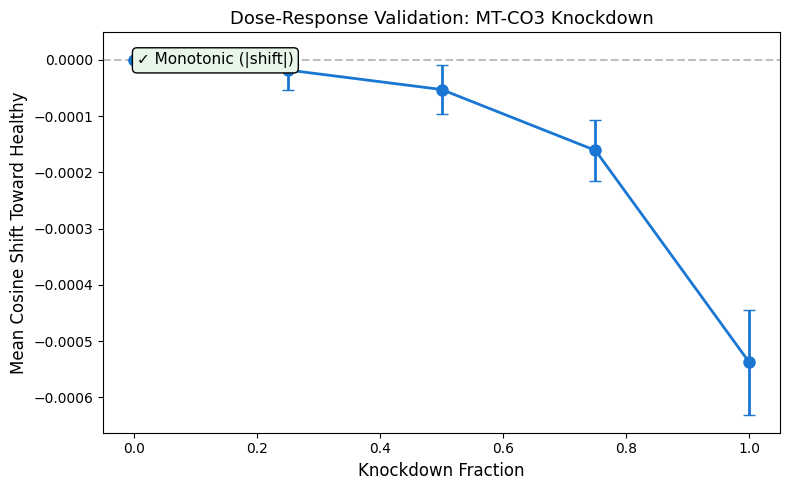


Figure saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/dose_response_validation.png
✓ Dose-response is monotonic — framework captures perturbation magnitude.


In [12]:
# ── VALIDATION 3: DOSE-RESPONSE LINEARITY ────────────────────────────────────
# Graded perturbation should produce monotonically increasing embedding shifts.
# This validates that the framework captures perturbation magnitude, not just
# presence/absence — a key advantage over binary perturbation approaches.

print("=== Validation 3: Dose-Response Check ===\n")

# Use same test gene from Validation 1
dose_df = perturber.dose_response(
    gene=test_gene,
    cell_subset=disease_mask_bool,
    goal_centroid=healthy_centroid,
    levels=DOSE_LEVELS,
    n_cells=DOSE_RESPONSE_N_CELLS
)

print("\nDose-response results:")
print(dose_df.to_string(index=False))

# Check monotonicity (of absolute shift — direction may be negative)
shifts = dose_df['mean_cosine_shift'].values
abs_shifts = np.abs(shifts)
is_monotonic = all(abs_shifts[i] <= abs_shifts[i+1] for i in range(len(abs_shifts)-1))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    dose_df['knockdown_fraction'], 
    dose_df['mean_cosine_shift'],
    yerr=dose_df['se_cosine_shift'],
    fmt='o-', color='#1976D2', linewidth=2, markersize=8, capsize=4
)
ax.set_xlabel('Knockdown Fraction', fontsize=12)
ax.set_ylabel('Mean Cosine Shift Toward Healthy', fontsize=12)
ax.set_title(f'Dose-Response Validation: {test_gene} Knockdown', fontsize=13)
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
ax.set_xlim(-0.05, 1.05)

# Annotate
mono_text = "✓ Monotonic (|shift|)" if is_monotonic else "⚠ Non-monotonic"
color = '#E8F5E9' if is_monotonic else '#FFF3E0'
ax.annotate(mono_text, xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=11, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))

plt.tight_layout()
fig_path = FIGURES_DIR / 'dose_response_validation.png'
plt.savefig(str(fig_path), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure saved: {fig_path}")

if is_monotonic:
    print("✓ Dose-response is monotonic — framework captures perturbation magnitude.")
else:
    print("⚠ Non-monotonic dose-response. This is not uncommon for some genes")
    print("  due to non-linear rank dynamics. Documented as limitation.")

---

## 6. Framework Summary and Scalability

### Validated Capabilities

| Feature | Status | Method |
|---------|--------|--------|
| **Knock-down (binary)** | ✓ | Count → 0 (rank deletion) |
| **Knock-up (overexpress)** | ✓ | Count → max+1 (rank position 1) |
| **Knock-up (restore)** | ✓ | Count → healthy mean (biologically grounded) |
| **Graded perturbation** | ✓ | Count × (1−fraction), dose-response |
| **Cosine shift metric** | ✓ | Field-standard (Theodoris et al. 2023) |
| **Null distribution** | ✓ | Random gene permutation + FDR |
| **Negative control** | ✓ | Housekeeping gene validation |
| **Dose-response** | ✓ | GeneCompass-inspired (Yang et al. 2024) |

### Scaling to Multiple Genes

The `InSilicoPerturbation` class is designed for batch operation:

```python
# Example: perturb 10 ALS genes across disease motor neurons
for gene, info in ALS_GENES.items():
    adata_pert = perturber.perturb(
        genes=[gene], 
        direction=info['direction'],
        cell_subset=(vat1l_mask & sals_mask),
        n_cells=200
    )
    embeddings[gene] = perturber.embed(adata_pert)
```

### Computational Considerations

- **GPU:** AWS g5.xlarge
- **Subsampling:** N=200 cells per condition balances statistical power with runtime
- **Memory:** Dense matrix conversion is per-perturbation; original sparse matrix preserved
- **Reproducibility:** All random operations seeded (`RANDOM_STATE=42`), PyTorch + NumPy + CUDA

### Reflections on methodological limitations

1. **No downstream cascade modelling:** Perturbation modifies only the target gene's count. Secondary regulatory effects (e.g., TDP-43 knockdown affecting hundreds of splicing targets) are not modelled. This is a known limitation of the embedding-shift paradigm vs. transcriptome prediction methods (STATE, scREPA).
2. **Rank-ordering sensitivity:** For genes near the expression boundary (low-count genes), small count changes can produce disproportionate rank shifts. Mitigated by focusing on well-expressed ALS-associated genes.
3. **Circularity in rescue scoring:** The healthy-disease embedding axis is partially defined by expression of the perturbed genes. Mitigated by (a) normalising rescue scores to a mean-healthy upper bound, and (b) comparing against a random-gene null distribution.